<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/ClusterdDataset%26SML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Dataset Analysis***

**1. Import Libraries**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import pickle

**2. Load and Inspect the Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DSGP/Siyumi/Modelnew/new/new_target_dataset.csv')

In [ ]:
#Display information
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64653 entries, 0 to 64652
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Gender_Female                64653 non-null  bool  
 1   Gender_Male                  64653 non-null  bool  
 2   Continent_Africa             64653 non-null  bool  
 3   Continent_Asia               64653 non-null  bool  
 4   Continent_Europe             64653 non-null  bool  
 5   Continent_North America      64653 non-null  bool  
 6   Continent_South America      64653 non-null  bool  
 7   Tobacco_Use_No               64653 non-null  bool  
 8   Tobacco_Use_Yes              64653 non-null  bool  
 9   Alcohol_Use_No               64653 non-null  bool  
 10  Alcohol_Use_Yes              64653 non-null  bool  
 11  HPV_Related_No               64653 non-null  bool  
 12  HPV_Related_Yes              64653 non-null  bool  
 13  Age_group_Middle 

In [ ]:
#Load 5 rows
print("\nFirst 5 rows:")
print(data.head())


First 5 rows:
   Gender_Female  Gender_Male  Continent_Africa  Continent_Asia  \
0          False         True              True           False   
1           True        False             False           False   
2           True        False             False           False   
3          False         True              True           False   
4          False         True             False           False   

   Continent_Europe  Continent_North America  Continent_South America  \
0             False                    False                    False   
1              True                    False                    False   
2              True                    False                    False   
3             False                    False                    False   
4              True                    False                    False   

   Tobacco_Use_No  Tobacco_Use_Yes  Alcohol_Use_No  Alcohol_Use_Yes  \
0           False             True           False             True   
1

**3. Understand Numerical Features**

In [ ]:
# View the shape of dataset
print("\nDataset Shape:")
print(data.shape)


Dataset Shape:
(64653, 20)


In [ ]:
# Label encoding categorical data
label_encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

In [ ]:
data.head()

,Gender_Female,Gender_Male,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_South America,Tobacco_Use_No,Tobacco_Use_Yes,Alcohol_Use_No,Alcohol_Use_Yes,HPV_Related_No,HPV_Related_Yes,Age_group_Middle,Age_group_Older,Age_group_Young,Socioeconomic_Status_High,Socioeconomic_Status_Low,Socioeconomic_Status_Middle,Risk_Level
0,False,True,True,False,False,False,False,False,True,False,True,True,False,False,False,True,True,False,False,1
1,True,False,False,False,True,False,False,False,True,False,True,True,False,False,True,False,True,False,False,0
2,True,False,False,False,True,False,False,False,True,False,True,False,True,False,True,False,False,False,True,0
3,False,True,True,False,False,False,False,False,True,False,True,True,False,True,False,False,False,False,True,1
4,False,True,False,False,True,False,False,False,True,False,True,True,False,False,False,True,False,False,True,1


Correlations with Target Column:
Gender_Female                 -0.042680
Gender_Male                    0.042680
Continent_Africa              -0.002653
Continent_Asia                 0.002165
Continent_Europe              -0.000527
Continent_North America       -0.000645
Continent_South America        0.001769
Tobacco_Use_No                 0.205409
Tobacco_Use_Yes               -0.205409
Alcohol_Use_No                -0.032849
Alcohol_Use_Yes                0.032849
HPV_Related_No                 0.031330
HPV_Related_Yes               -0.031330
Age_group_Middle              -0.067652
Age_group_Older                0.011275
Age_group_Young                0.049483
Socioeconomic_Status_High      0.231926
Socioeconomic_Status_Low      -0.519099
Socioeconomic_Status_Middle    0.326797
Name: Risk_Level, dtype: float64


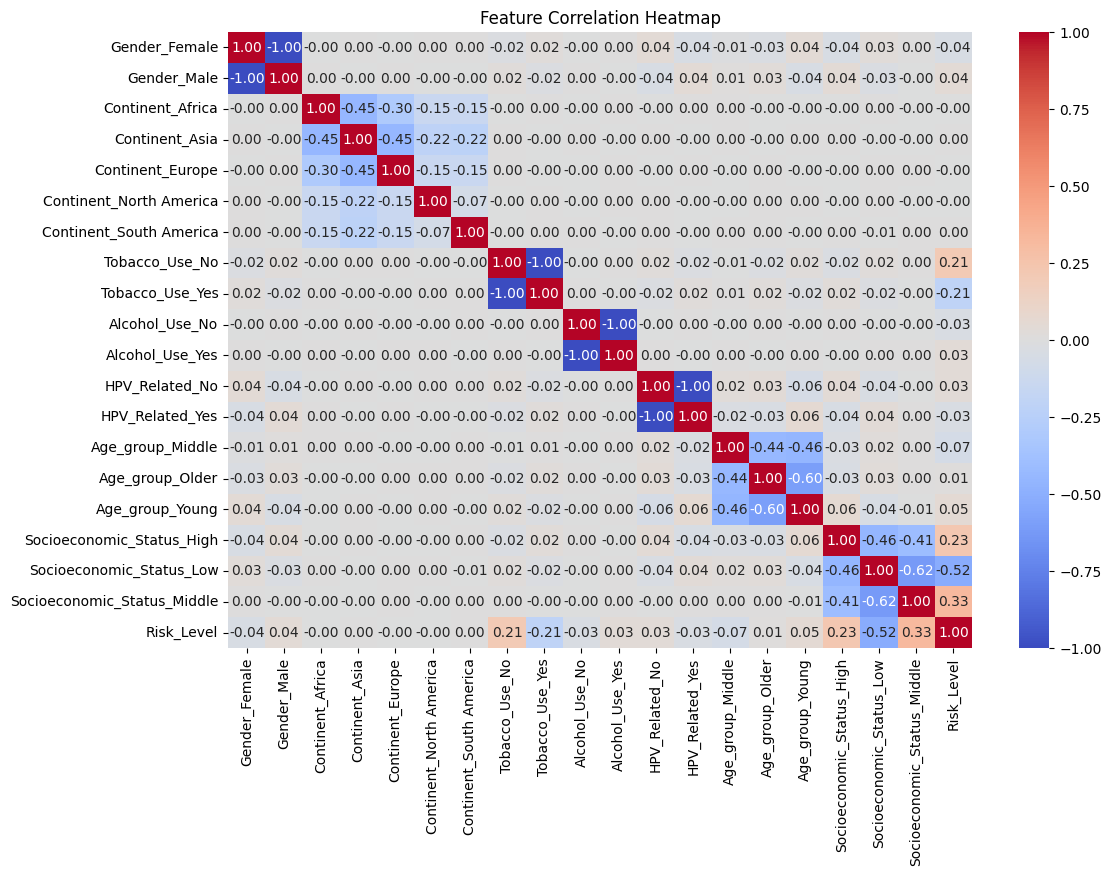

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'Risk_Level' is your target column
target_column = 'Risk_Level'

# Calculate correlations with target
correlations = data.corr()[target_column].drop(target_column)  # Exclude target from the result

# Print correlations
print("Correlations with Target Column:")
print(correlations)

# Now proceed with the heatmap code
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# **Visualize Relationship Between  features and the target variable**

**Scatter Plot Matrix (Pairplot)**

In [ ]:
#import pandas as pd
#import seaborn as sns
#import matplotlib.pyplot as plt

# Load your dataset
#data = pd.read_csv('/content/drive/MyDrive/DSGP/Siyumi/Modelnew/new/new_target_dataset.csv')

# Pairplot to visualize scatter plots
#sns.pairplot(data, diag_kind="kde")
#plt.show()

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/DSGP/Siyumi/Modelnew/new/new_target_dataset.csv')

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# List of categorical features including the target variable
categorical_features = ['Gender_Female','Gender_Male','Continent_Africa','Continent_Asia','Continent_Europe','Continent_North America','Continent_South America','Tobacco_Use_No','Tobacco_Use_Yes','Alcohol_Use_No','Alcohol_Use_Yes','HPV_Related_No','HPV_Related_Yes','Age_group_Middle','Age_group_Older','Age_group_Young','Socioeconomic_Status_High','Socioeconomic_Status_Low','Socioeconomic_Status_Middle', 'Risk_Level']

# Apply Label Encoding to categorical features
for feature in categorical_features:
    data[feature] = label_encoder.fit_transform(data[feature])

# List of features for correlation analysis (excluding the target 'Risk_Level')
features = ['Gender_Female','Gender_Male','Continent_Africa','Continent_Asia','Continent_Europe','Continent_North America','Continent_South America','Tobacco_Use_No','Tobacco_Use_Yes','Alcohol_Use_No','Alcohol_Use_Yes','HPV_Related_No','HPV_Related_Yes','Age_group_Middle','Age_group_Older','Age_group_Young','Socioeconomic_Status_High','Socioeconomic_Status_Low','Socioeconomic_Status_Middle']

# Calculate and print Pearson correlations
for feature in features:
    correlation, p_value = pearsonr(data[feature], data['Risk_Level'])
    print(f"{feature}: Pearson correlation = {correlation:.3f}, p-value = {p_value:.3f}")

Gender_Female: Pearson correlation = -0.043, p-value = 0.000
Gender_Male: Pearson correlation = 0.043, p-value = 0.000
Continent_Africa: Pearson correlation = -0.003, p-value = 0.500
Continent_Asia: Pearson correlation = 0.002, p-value = 0.582
Continent_Europe: Pearson correlation = -0.001, p-value = 0.893
Continent_North America: Pearson correlation = -0.001, p-value = 0.870
Continent_South America: Pearson correlation = 0.002, p-value = 0.653
Tobacco_Use_No: Pearson correlation = 0.205, p-value = 0.000
Tobacco_Use_Yes: Pearson correlation = -0.205, p-value = 0.000
Alcohol_Use_No: Pearson correlation = -0.033, p-value = 0.000
Alcohol_Use_Yes: Pearson correlation = 0.033, p-value = 0.000
HPV_Related_No: Pearson correlation = 0.031, p-value = 0.000
HPV_Related_Yes: Pearson correlation = -0.031, p-value = 0.000
Age_group_Middle: Pearson correlation = -0.068, p-value = 0.000
Age_group_Older: Pearson correlation = 0.011, p-value = 0.004
Age_group_Young: Pearson correlation = 0.049, p-value

In [ ]:
#data = data.drop(columns=[
 #   'Continent_Africa',           # Drop as it has very low correlation with the target
  # 'Continent_Europe',           # Drop as it has very low correlation with the target
   # 'Continent_North America',    # Drop as it has very low correlation with the target
  #  'Continent_South America',    # Drop as it has very low correlation with the target
   # 'Gender_Male',                # Drop because Gender_Female already captures the gender information
   # 'Tobacco_Use_No',             # Drop as it is complementary to Tobacco_Use_Yes
   # 'HPV_Related_No',             # Drop as it is complementary to HPV_Related_Yes
  #  'Alcohol_Use_No',             # Drop as it is complementary to Alcohol_Use_Yes
   # 'Socioeconomic_Status_Middle',# Drop to reduce redundancy in socioeconomic status
   # 'Socioeconomic_Status_High',  # Drop to reduce redundancy in socioeconomic status
   # 'Age_group_Middle'
#])

**4. Histograms for Numerical Features**

**5. Box Plot to Identify Outliers**

**7. Understand Categorical Features**

**8. Unique values of each column**

**12. Map Target Variable**

**13. Check Imbalacing of Dataset**

**14. Handle Imbalancing Uning SMOTE**

**15. Correlation Analysis**

**16. Visualization of Correlation values**

**17. Features Selection**

**18. Dataset Splitting**

In [ ]:
# Print remaining features
print("\nRemaining features after dropping unnecessary columns:")
print(list(data.columns))


Remaining features after dropping unnecessary columns:
['Gender_Female', 'Gender_Male', 'Continent_Africa', 'Continent_Asia', 'Continent_Europe', 'Continent_North America', 'Continent_South America', 'Tobacco_Use_No', 'Tobacco_Use_Yes', 'Alcohol_Use_No', 'Alcohol_Use_Yes', 'HPV_Related_No', 'HPV_Related_Yes', 'Age_group_Middle', 'Age_group_Older', 'Age_group_Young', 'Socioeconomic_Status_High', 'Socioeconomic_Status_Low', 'Socioeconomic_Status_Middle', 'Risk_Level']


In [ ]:
#download feature_names.pkl file
import pickle
with open('feature_names.pkl', 'wb') as file:
    pickle.dump(list(data.columns), file)

In [ ]:
X = data.drop('Risk_Level', axis=1)  # Features
y = data['Risk_Level']  # Target variable

# Now you can use train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 45257
Test set size: 19396


In [ ]:
y.value_counts()

,count
Risk_Level,
1,25517
0,21504
2,17632


In [ ]:
from imblearn.over_sampling import SMOTE

# Assuming X_train and y_train are your training features and labels
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Apply SMOTE to the training dataset
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
# Print the count of each class in the resampled data
print("Balanced class distribution in y_train:")
print(y_train_resampled.value_counts())

Balanced class distribution in y_train:
Risk_Level
1    17824
0    17824
2    17824
Name: count, dtype: int64


**19. Feature Scaling**

In [ ]:
#stander scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#save scaler to pickle file
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)


Cross-Validation Accuracy: 0.9329 ± 0.0016

Training Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     15121
           1       0.96      0.94      0.95     17824
           2       0.87      0.92      0.90     12312

    accuracy                           0.93     45257
   macro avg       0.93      0.93      0.93     45257
weighted avg       0.93      0.93      0.93     45257


Testing Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      6383
           1       0.96      0.94      0.95      7693
           2       0.88      0.93      0.90      5320

    accuracy                           0.94     19396
   macro avg       0.93      0.93      0.93     19396
weighted avg       0.94      0.94      0.94     19396



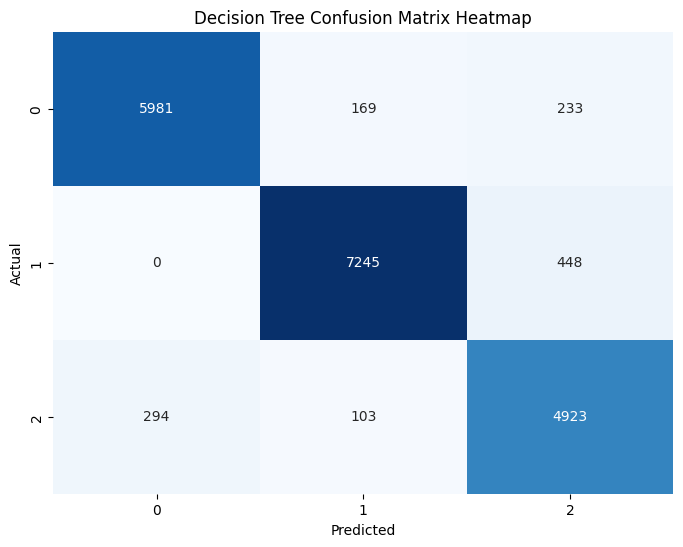

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Cross-validation with accuracy scoring
cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model on the full training data
dt_model.fit(X_train_scaled, y_train)

# Predictions on the training set
y_train_pred = dt_model.predict(X_train_scaled)

# Predictions on the test set
y_test_pred = dt_model.predict(X_test_scaled)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix Heatmap')
plt.show()

with open('Decision_Tree_Classifier.pkl', 'wb') as file:
    pickle.dump(dt_model, file)


Cross-Validation Accuracy: 0.9496 ± 0.0065

Training Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     15121
           1       0.95      0.98      0.96     17824
           2       0.95      0.92      0.93     12312

    accuracy                           0.95     45257
   macro avg       0.95      0.95      0.95     45257
weighted avg       0.95      0.95      0.95     45257


Testing Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      6383
           1       0.95      0.98      0.96      7693
           2       0.96      0.92      0.94      5320

    accuracy                           0.95     19396
   macro avg       0.95      0.95      0.95     19396
weighted avg       0.95      0.95      0.95     19396



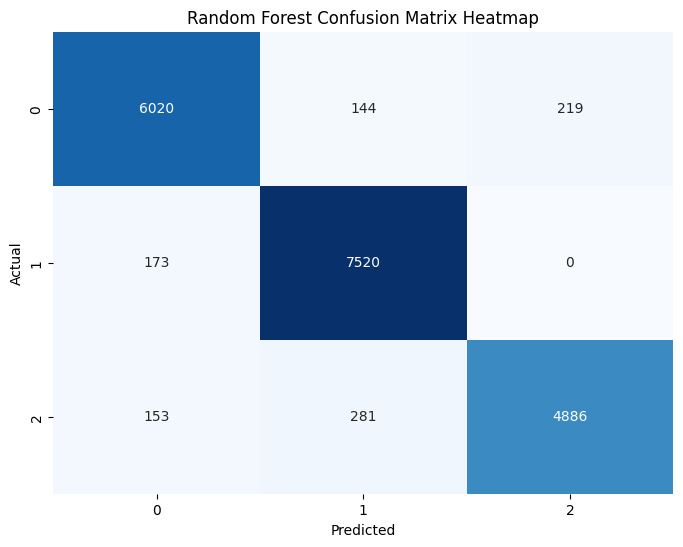

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Random Forest model with max_depth
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)

# Cross-validation with accuracy scoring
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model on the full training data
rf_model.fit(X_train_scaled, y_train)

# Predictions on the training set
y_train_pred = rf_model.predict(X_train_scaled)

# Predictions on the test set
y_test_pred = rf_model.predict(X_test_scaled)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix Heatmap')
plt.show()

with open('Random_Forest_Classifier.pkl', 'wb') as file:
    pickle.dump(dt_model, file)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Scaling the data (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define parameter grid for GridSearchCV with a smaller search space
param_grid = {
    'C': [0.1, 1, 10, 100],  # Smaller range for C
    'kernel': ['rbf', 'linear'],  # Try both 'rbf' and 'linear' kernel
    'gamma': ['scale', 'auto'],  # Try different gamma options
}

# Initialize the SVM model
svm_model = SVC(random_state=42)

# Grid Search with cross-validation
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best parameters found by Grid Search
print(f"Best Parameters: {grid_search.best_params_}")

# Use the best estimator found from Grid Search
best_svm_model = grid_search.best_estimator_

# Predictions on the train and test set
y_pred_train = best_svm_model.predict(X_train_scaled)
y_pred_test = best_svm_model.predict(X_test_scaled)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_pred_train))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_pred_test))

# Cross-validation scores on the training data
cv_scores = cross_val_score(best_svm_model, X_train_scaled, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix Heatmap')
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Gradient Boosting model
gbm_model = GradientBoostingClassifier(n_estimators=50,max_depth=3, random_state=42)

# Cross-validation with accuracy scoring
cv_scores = cross_val_score(gbm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model on the full training data
gbm_model.fit(X_train_scaled, y_train)

# Predictions on the training set
y_train_pred = gbm_model.predict(X_train_scaled)

# Predictions on the test set
y_test_pred = gbm_model.predict(X_test_scaled)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting Confusion Matrix Heatmap')
plt.show()

with open('Gradient_Boosting_Classifier.pkl', 'wb') as file:
    pickle.dump(dt_model, file)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

# Initialize XGBoost Classifier with weak hyperparameters
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    learning_rate=0.5,          # High learning rate → Instability
    n_estimators=10,            # Fewer trees → Underfitting
    max_depth=2,                # Shallow trees → Limited complexity
    subsample=0.5,              # Train on half of the data → Increases variance
    colsample_bytree=0.5        # Use only half of the features → Increases bias
)

# Train the model
model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Classification Reports
print("Training Classification Report:\n")
print(classification_report(y_train, y_train_pred))

print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))

# Accuracy Scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Confusion Matrix
print("\nConfusion Matrix (Test):\n")
print(confusion_matrix(y_test, y_test_pred))

# Save the model
with open('XGBoost_Classifier.pkl', 'wb') as file:
    pickle.dump(model, file)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression for multiclass (using softmax)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Cross-validation (5 folds)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Set Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

with open('Logistic_Regression.pkl', 'wb') as file:
    pickle.dump(dt_model, file)

In [ ]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load trained models
with open('Logistic_Regression.pkl', 'rb') as file:
    lr_model = pickle.load(file)

with open('Decision_Tree_Classifier.pkl', 'rb') as file:
    dt_model = pickle.load(file)

with open('Random_Forest_Classifier.pkl', 'rb') as file:
    rf_model = pickle.load(file)

with open('Gradient_Boosting_Classifier.pkl', 'rb') as file:
    gbm_model = pickle.load(file)

with open('XGBoost_Classifier.pkl', 'rb') as file:
    xgb_model = pickle.load(file)

# Load scaler and feature names from training
with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

with open('feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)  # Ensure correct feature order

# Define possible values for categorical features (One-Hot Encoding)
categorical_options = {
    'Gender': ['Female', 'Male'],
    'Continent': ['Africa', 'Asia', 'Europe', 'North America', 'South America'],
    'Socioeconomic_Status': ['High', 'Low', 'Middle'],
    'Tobacco_Use': ['No', 'Yes'],
    'Alcohol_Use': ['No', 'Yes'],
    'HPV_Related': ['No', 'Yes']
}

numerical_features = ['Age']  # Only Age is numeric

# Function to get user input
def get_user_input():
    """Collect user input and prepare for prediction"""
    user_data = {}

    print("\n🔹 Enter values for the following features:")

    # Get numerical input
    user_data['Age'] = float(input("   Age: "))

    # Get categorical input
    for feature, options in categorical_options.items():
        print(f"   {feature} Options: {options}")
        user_data[feature] = input(f"   {feature}: ").strip()

        # Validate input
        if user_data[feature] not in options:
            print(f"⚠️ Warning: Invalid value '{user_data[feature]}' for {feature}. Using default '{options[0]}'.")
            user_data[feature] = options[0]

    return user_data

# Take user input
user_data = get_user_input()

# Convert input data to One-Hot Encoding format
input_df = pd.DataFrame(columns=[col for col in feature_names if col != 'Risk_Level'])
input_df.loc[0] = 0  # Initialize all values to 0

# Assign numerical values
input_df.at[0, 'Age'] = user_data['Age']

# Assign categorical values in One-Hot Encoding format
for feature, options in categorical_options.items():
    column_name = f"{feature}_{user_data[feature]}"
    if column_name in input_df.columns:
        input_df.at[0, column_name] = 1  # Set the correct category to 1

# Ensure the input_df has the correct columns as expected by the model
input_df = input_df[[col for col in feature_names if col != 'Risk_Level']]  # Reorder and filter columns to match the model's training order

# Standard Scaling (Use same scaler from training)
input_scaled = scaler.transform(input_df)

# ✅ Predict using Logistic Regression
lr_prob = lr_model.predict_proba(input_scaled)[0]
lr_pred = lr_model.predict(input_scaled)[0]

# ✅ Predict using Decision Tree
dt_prob = dt_model.predict_proba(input_scaled)[0]
dt_pred = dt_model.predict(input_scaled)[0]

# ✅ Predict using Random Forest
rf_prob = rf_model.predict_proba(input_scaled)[0]
rf_pred = rf_model.predict(input_scaled)[0]

# ✅ Predict using Gradient Boosting
gbm_prob = gbm_model.predict_proba(input_scaled)[0]
gbm_pred = gbm_model.predict(input_scaled)[0]

# ✅ Predict using XGBoost
xgb_prob = xgb_model.predict_proba(input_scaled)[0]
xgb_pred = xgb_model.predict(input_scaled)[0]

# ================== DISPLAY RESULTS ==================
def display_results(model_name, pred, prob):
    print(f"\n🔹 {model_name} Model Prediction:")
    print(f"   🟢 Low Risk Probability: {prob[0]:.4f}")
    print(f"   🟠 Medium Risk Probability: {prob[1]:.4f}")
    print(f"   🔴 High Risk Probability: {prob[2]:.4f}")

    if pred == 2:
        print("   🛑 **Final Prediction: High Risk**")
    elif pred == 1:
        print("   ⚠️ **Final Prediction: Medium Risk**")
    else:
        print("   ✅ **Final Prediction: Low Risk**")

# 🚀 Display predictions from all models
display_results("Logistic Regression", lr_pred, lr_prob)
display_results("Decision Tree", dt_pred, dt_prob)
display_results("Random Forest", rf_pred, rf_prob)
display_results("Gradient Boosting", gbm_pred, gbm_prob)
display_results("XGBoost", xgb_pred, xgb_prob)

# ✅ Final decision based on highest probability from all models
final_pred = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gbm_pred,
    'XGBoost': xgb_pred
}

final_result = max(final_pred, key=final_pred.get)

print("\n✨ **Final Consensus Prediction:**")
if final_pred[final_result] == 2:
    print(f"   🛑 {final_result} predicts **High Risk**")
elif final_pred[final_result] == 1:
    print(f"   ⚠️ {final_result} predicts **Medium Risk**")
else:
    print(f"   ✅ {final_result} predicts **Low Risk**")

FileNotFoundError: [Errno 2] No such file or directory: 'Logistic_Regression.pkl'


Cross-Validation Accuracy: 1.0000 ± 0.0000

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15121
           1       1.00      1.00      1.00     17824
           2       1.00      1.00      1.00     12312

    accuracy                           1.00     45257
   macro avg       1.00      1.00      1.00     45257
weighted avg       1.00      1.00      1.00     45257


Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6383
           1       1.00      1.00      1.00      7693
           2       1.00      1.00      1.00      5320

    accuracy                           1.00     19396
   macro avg       1.00      1.00      1.00     19396
weighted avg       1.00      1.00      1.00     19396



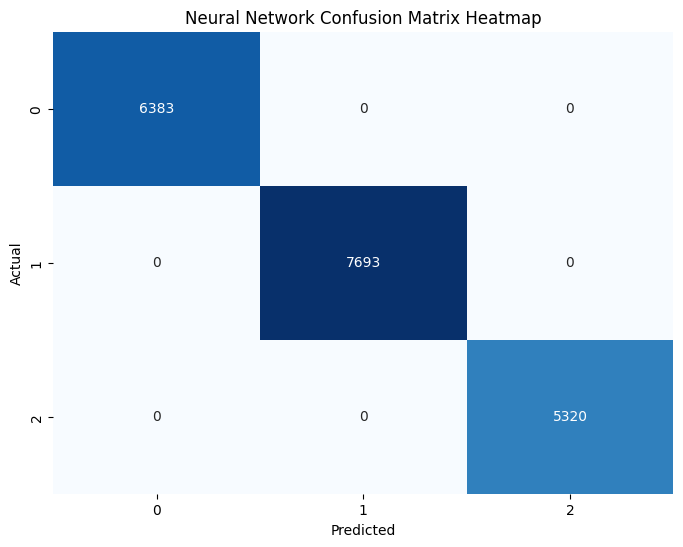

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Neural Network (MLP) model with regularization
mlp_model = MLPClassifier(
    hidden_layer_sizes=(30,),  # Reduced neurons
    max_iter=100,              # Fewer iterations to avoid overfitting
    alpha=0.001,               # Regularization to prevent overfitting
    random_state=42,
    early_stopping=True,       # Stops if validation score stops improving
    validation_fraction=0.2    # 20% of training data used for validation
)

# Cross-validation with accuracy scoring
cv_scores = cross_val_score(mlp_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit the model on the full training data
mlp_model.fit(X_train_scaled, y_train)

# Predictions on the training set
y_train_pred = mlp_model.predict(X_train_scaled)

# Predictions on the test set
y_test_pred = mlp_model.predict(X_test_scaled)

# Evaluation metrics for training data
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluation metrics for testing data
print("\nTesting Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for testing data
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix Heatmap')
plt.show()


Cross-Validation Accuracy: 1.0000 ± 0.0000

Test Set Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7330
           1       1.00      1.00      1.00      5587
           2       1.00      1.00      1.00      6479

    accuracy                           1.00     19396
   macro avg       1.00      1.00      1.00     19396
weighted avg       1.00      1.00      1.00     19396


Confusion Matrix:
[[7330    0    0]
 [   0 5587    0]
 [   0    0 6479]]


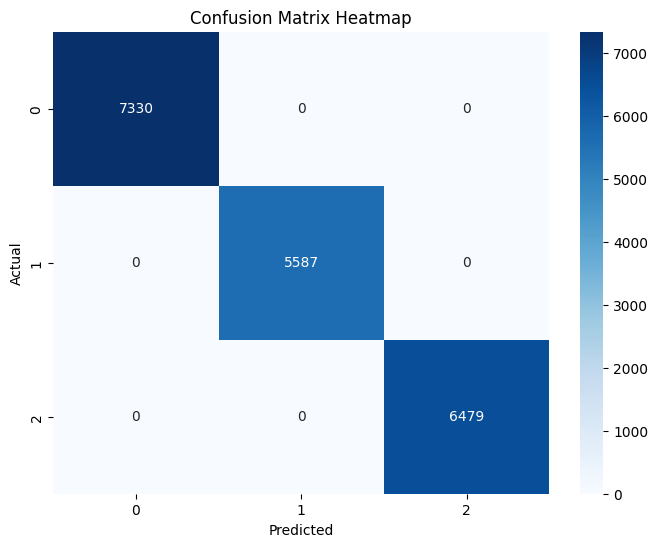

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Decision Tree classifier with optimized hyperparameters
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Cross-validation (More reliable accuracy estimate)
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5)
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Set Accuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
import pickle

# 🚀 Step 1: Initialize Logistic Regression Model with Hyperparameters
model = LogisticRegression(
    C=0.1,                    # Regularization strength
    penalty='l2',             # L2 (Ridge) regularization
    solver='liblinear',       # Solver that supports L2 penalty
    random_state=42
)

# 🚀 Step 2: Cross-Validation on Training Data (5-Fold)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\n🔹 Cross-Validation Scores: {cv_scores}")
print(f"🔹 Average CV Score: {cv_scores.mean():.4f}")

# 🚀 Step 3: Train Model on Full Training Data
model.fit(X_train_scaled, y_train)

# 🚀 Step 4: Predictions
y_pred_lr_train = model.predict(X_train_scaled)
y_pred_lr_test = model.predict(X_test_scaled)

# 🚀 Step 5: Classification Reports
print("\n🔹 Logistic Regression Classification Report (Train):")
print(classification_report(y_train, y_pred_lr_train))

print("\n🔹 Logistic Regression Classification Report (Test):")
print(classification_report(y_test, y_pred_lr_test))

# 🚀 Step 6: Save Model
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)


🔹 Cross-Validation Scores: [0.73099867 0.73563853 0.73450447 0.73571981 0.7262181 ]
🔹 Average CV Score: 0.7326

🔹 Logistic Regression Classification Report (Train):
              precision    recall  f1-score   support

           0       0.82      0.68      0.74     15121
           1       0.75      0.88      0.81     17824
           2       0.61      0.58      0.59     12312

    accuracy                           0.73     45257
   macro avg       0.73      0.71      0.72     45257
weighted avg       0.73      0.73      0.73     45257


🔹 Logistic Regression Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.69      0.75      6383
           1       0.75      0.87      0.81      7693
           2       0.61      0.59      0.60      5320

    accuracy                           0.73     19396
   macro avg       0.73      0.72      0.72     19396
weighted avg       0.74      0.73      0.73     19396



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pickle

#Step 1: Initialize Logistic Regression Model
model = LogisticRegression(random_state=42)

#Step 2: Train Model on Training Data
model.fit(X_train_scaled, y_train)

#Step 3: Predictions
y_pred_lr_train = model.predict(X_train_scaled)
y_pred_lr_test = model.predict(X_test_scaled)

#Step 4: Classification Reports
print("\n🔹 Logistic Regression Classification Report (Train):")
print(classification_report(y_train, y_pred_lr_train))

print("\n🔹 Logistic Regression Classification Report (Test):")
print(classification_report(y_test, y_pred_lr_test))


🔹 Logistic Regression Classification Report (Train):
              precision    recall  f1-score   support

           0       0.61      0.65      0.63     17122
           1       0.63      0.69      0.66     12751
           2       0.74      0.63      0.68     15384

    accuracy                           0.65     45257
   macro avg       0.66      0.66      0.66     45257
weighted avg       0.66      0.65      0.66     45257


🔹 Logistic Regression Classification Report (Test):
              precision    recall  f1-score   support

           0       0.62      0.65      0.63      7330
           1       0.63      0.69      0.66      5587
           2       0.73      0.63      0.67      6479

    accuracy                           0.65     19396
   macro avg       0.66      0.66      0.66     19396
weighted avg       0.66      0.65      0.65     19396



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.metrics import classification_report
!pip install lightgbm
from lightgbm import LGBMClassifier

# XGBoost Model
xgb_model = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb_train = xgb_model.predict(X_train_scaled)
y_pred_xgb_test = xgb_model.predict(X_test_scaled)
print("\n🔹 XGBoost Classification Report (Train):")
print(classification_report(y_train, y_pred_xgb_train))
print("\n🔹 XGBoost Classification Report (Test):")
print(classification_report(y_test, y_pred_xgb_test))

# Logistic Regression Model
lr_model = LogisticRegression(random_state=42, C=1.0, penalty='l2', solver='liblinear')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)
print("\n🔹 Logistic Regression Classification Report (Train):")
print(classification_report(y_train, y_pred_lr_train))
print("\n🔹 Logistic Regression Classification Report (Test):")
print(classification_report(y_test, y_pred_lr_test))

# Random Forest Model with max_depth
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)  # Set max_depth as needed
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Classification Reports
print("\n🔹 Random Forest Classification Report (Train):")
print(classification_report(y_train, y_pred_rf_train))

print("\n🔹 Random Forest Classification Report (Test):")
print(classification_report(y_test, y_pred_rf_test))

# LightGBM Model
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_scaled, y_train)
y_pred_lgb_train = lgb_model.predict(X_train_scaled)
y_pred_lgb_test = lgb_model.predict(X_test_scaled)
print("\n🔹 LightGBM Classification Report (Train):")
print(classification_report(y_train, y_pred_lgb_train))
print("\n🔹 LightGBM Classification Report (Test):")
print(classification_report(y_test, y_pred_lgb_test))


with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)
with open('lightGBM_model.pkl', 'wb') as file:
    pickle.dump(lgb_model, file)

print("\n✅ All models updated and saved successfully.")


🔹 XGBoost Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17122
           1       1.00      1.00      1.00     12751
           2       1.00      1.00      1.00     15384

    accuracy                           1.00     45257
   macro avg       1.00      1.00      1.00     45257
weighted avg       1.00      1.00      1.00     45257


🔹 XGBoost Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7330
           1       1.00      1.00      1.00      5587
           2       1.00      1.00      1.00      6479

    accuracy                           1.00     19396
   macro avg       1.00      1.00      1.00     19396
weighted avg       1.00      1.00      1.00     19396


🔹 Logistic Regression Classification Report (Train):
              precision    recall  f1-score   support

           0       0.62      0.65      0.63   

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



🔹 LightGBM Classification Report (Train):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17122
           1       1.00      1.00      1.00     12751
           2       1.00      1.00      1.00     15384

    accuracy                           1.00     45257
   macro avg       1.00      1.00      1.00     45257
weighted avg       1.00      1.00      1.00     45257


🔹 LightGBM Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7330
           1       1.00      1.00      1.00      5587
           2       1.00      1.00      1.00      6479

    accuracy                           1.00     19396
   macro avg       1.00      1.00      1.00     19396
weighted avg       1.00      1.00      1.00     19396


✅ All models updated and saved successfully.


In [ ]:
#print pickle version
import pickle
print(pickle.format_version)

4.0


In [ ]:
#print joblib version
import joblib
print(joblib.__version__)

1.4.2


In [ ]:
#print Torchvision version
import torchvision
print(torchvision.__version__)

0.20.1+cu124


In [ ]:
#print pytorch version
import torch
print(torch.__version__)

2.5.1+cu124


In [ ]:
pip install shap

TypeError: only integer scalar arrays can be converted to a scalar index

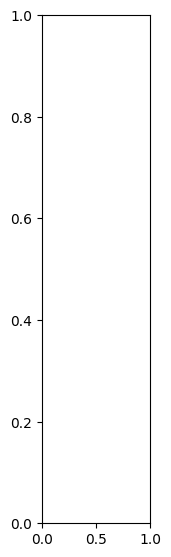

In [ ]:
import shap
import matplotlib.pyplot as plt

# Assuming your model, scaler, and input_df are already defined
# Generate SHAP values for the input data
explainer = shap.Explainer(lr_model, input_scaled)  # lr_model is your trained model and input_scaled is your scaled input
shap_values = explainer(input_scaled)

# Plot SHAP summary plot
shap.summary_plot(shap_values, input_df)

# Optional: SHAP waterfall plot for a single prediction (choose an index, here it's 0)
shap.waterfall_plot(shap_values[0])

# Optional: SHAP bar plot for a single prediction
shap.bar_plot(shap_values[0])

# Show the plots
plt.show()

In [ ]:
pip install tensorflow scikit-learn numpy matplotlib

In [ ]:
pip install tensorflow

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Reduce trees for better generalization
    'max_depth': [5, 10, 15, None],  # Limit tree depth to avoid memorization
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5],  # Minimum samples in a leaf node
    'max_features': ['sqrt', 'log2']  # Limits number of features per split
}

# Perform Grid Search with 5-Fold Cross-Validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# Retrieve best model
best_rf_model = grid_search.best_estimator_

# Print best hyperparameters
print("\n🔹 Best Hyperparameters for Random Forest:")
print(grid_search.best_params_)

# Train best model on full training data
best_rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = best_rf_model.predict(X_train_scaled)
y_pred_rf_test = best_rf_model.predict(X_test_scaled)

# Classification Reports
print("\n🔹 Random Forest Classification Report (Train):")
print(classification_report(y_train, y_pred_rf_train))

print("\n🔹 Random Forest Classification Report (Test):")
print(classification_report(y_test, y_pred_rf_test))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pickle
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Define Stratified K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to evaluate model with Cross-Validation
def evaluate_model(model, X, y):
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    print(f"\n🔹 {model.__class__.__name__} - Cross-Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# Train and Evaluate Models

# XGBoost Model
xgb_model = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_estimators=100, learning_rate=0.1)
evaluate_model(xgb_model, X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

# Logistic Regression Model
lr_model = LogisticRegression(random_state=42, C=0.1, penalty='l2', solver='liblinear')  # Applied stronger regularization
evaluate_model(lr_model, X_train_scaled, y_train)
lr_model.fit(X_train_scaled, y_train)

# Random Forest Model with max_depth
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)  # Added max_depth for better generalization
evaluate_model(rf_model, X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# LightGBM Model
lgb_model = LGBMClassifier(random_state=42)
evaluate_model(lgb_model, X_train_scaled, y_train)
lgb_model.fit(X_train_scaled, y_train)

# Final Predictions (for classification report on the test set)
models = {"XGBoost": xgb_model, "Logistic Regression": lr_model, "Random Forest": rf_model, "LightGBM": lgb_model}
for name, model in models.items():
    y_pred_test = model.predict(X_test_scaled)
    print(f"\n🔹 {name} Classification Report (Test):")
    print(classification_report(y_test, y_pred_test))

# Save Models
for name, model in models.items():
    with open(f"{name.lower().replace(' ', '_')}_model.pkl", "wb") as file:
        pickle.dump(model, file)

print("\n✅ All models updated, cross-validated, and saved successfully.")


🔹 XGBClassifier - Cross-Validation Accuracy: 1.0000 ± 0.0000

🔹 LogisticRegression - Cross-Validation Accuracy: 0.9694 ± 0.0014

🔹 RandomForestClassifier - Cross-Validation Accuracy: 1.0000 ± 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 119
[LightGBM] [Info] Number of data points in the train set: 36205, number of used features: 17
[LightGBM] [Info] Start training from score -0.985027
[LightGBM] [Info] Start training from score -1.330146
[LightGBM] [Info] Start training from score -1.015746
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 119
[LightGBM] [Info] Number of data points in the train set: 36205, number of used features: 17
[LightGBM] [Info] Start training from score -0.985027
[LightGBM] [Info] Start training from score -1.330146
[LightGBM] [Info] Start training from score -1.015746
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 119
[LightGBM] [Info] Number of data points in the train set: 36206, number of used features: 17
[LightGBM] [Info] Start training from score -0.985055
[LightGBM] [Info] Start training from score -1.330174
[LightGBM] [Info] Start training from score -1.015697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



🔹 LGBMClassifier - Cross-Validation Accuracy: 1.0000 ± 0.0000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008968 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 119
[LightGBM] [Info] Number of data points in the train set: 45257, number of used features: 17
[LightGBM] [Info] Start training from score -0.985044
[LightGBM] [Info] Start training from score -1.330121
[LightGBM] [Info] Start training from score -1.015747
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



🔹 LightGBM Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7163
           1       1.00      1.00      1.00      5137
           2       1.00      1.00      1.00      7096

    accuracy                           1.00     19396
   macro avg       1.00      1.00      1.00     19396
weighted avg       1.00      1.00      1.00     19396


✅ All models updated, cross-validated, and saved successfully.


In [ ]:
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
nn_model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train_scaled, to_categorical(y_train), epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# Evaluate on Training and Testing Data
y_pred_nn_train = np.argmax(nn_model.predict(X_train_scaled), axis=1)
y_pred_nn_test = np.argmax(nn_model.predict(X_test_scaled), axis=1)

print("\n🔹 Neural Network Classification Report (Train):")
print(classification_report(y_train, y_pred_nn_train))
print("\n🔹 Neural Network Classification Report (Test):")
print(classification_report(y_test, y_pred_nn_test))

# Save the trained model
nn_model.save('nn_model.h5')
print("\n✅ Neural Network model saved successfully.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9657 - loss: 0.0960 - val_accuracy: 1.0000 - val_loss: 6.0922e-07
Epoch 2/100
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9999 - loss: 4.2097e-04 - val_accuracy: 1.0000 - val_loss: 5.0879e-07
Epoch 3/100


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Build the Neural Network model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),  # Increased neurons
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0005),  # Reduced learning rate for stability
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train,
                    validation_split=0.1,
                    epochs=100,  # Increased epochs for better training
                    batch_size=32,
                    verbose=1)

# Evaluate the model on the test data
train_loss, train_accuracy = model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n🔹 Training Accuracy: {train_accuracy:.2f}")
print(f"🔹 Test Accuracy: {test_accuracy:.2f}")

# Make predictions
y_prob_nn = model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_prob_nn, axis=1)

# Classification report and ROC-AUC score
print("\n🔹 Neural Network Classification Report on Test Data:")
print(classification_report(y_test, y_pred_nn))
print(f"🔹 Neural Network ROC-AUC Score on Test Data: {roc_auc_score(y_test, y_prob_nn, multi_class='ovr'):.2f}")

# Classification report for training data
y_train_prob_nn = model.predict(X_train_scaled)
y_train_pred_nn = np.argmax(y_train_prob_nn, axis=1)

print("\n🔹 Neural Network Classification Report on Training Data:")
print(classification_report(y_train, y_train_pred_nn))
print(f"🔹 Neural Network ROC-AUC Score on Training Data: {roc_auc_score(y_train, y_train_prob_nn, multi_class='ovr'):.2f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# Save the trained model
model.save('nn_model.h5')

print("\n✅ Neural Network model saved as 'nn_model.h5'.")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1168/2080 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0000e+00 - loss: nan

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-48-b4c60bce3144>", line 26, in <cell line: 0>
    history = model.fit(X_train_scaled, y_train,
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 372, in fit
    callbacks.on_train_batch_end(step, logs)
  File "/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py", line 172, in on_train_batch_end
    self._on_train_batch_end(batch, logs)
  File "/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py", line 194, in _on_train_batch_end
    callback.on_train_batch_end

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-48-b4c60bce3144>", line 26, in <cell line: 0>
    history = model.fit(X_train_scaled, y_train,
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 372, in fit
    callbacks.on_train_batch_end(step, logs)
  File "/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py", line 172, in on_train_batch_end
    self._on_train_batch_end(batch, logs)
  File "/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py", line 194, in _on_train_batch_end
    callback.on_train_batch_end

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-48-b4c60bce3144>", line 26, in <cell line: 0>
    history = model.fit(X_train_scaled, y_train,
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 372, in fit
    callbacks.on_train_batch_end(step, logs)
  File "/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py", line 172, in on_train_batch_end
    self._on_train_batch_end(batch, logs)
  File "/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py", line 194, in _on_train_batch_end
    callback.on_train_batch_end

In [ ]:
import pickle
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from google.colab import files


# Initialize XGBoost Regressor
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100, learning_rate=0.1)

# Train the model
xgb_model.fit(X_train_scaled, y_train)

# Predict on Test Data
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\n🔹 XGBoost Regression Metrics on Test Data:")
print(f"   🔹 Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_xgb):.4f}")
print(f"   🔹 R-squared Score (R²): {r2_score(y_test, y_pred_xgb):.4f}")

# Predict on Training Data
y_train_pred_xgb = xgb_model.predict(X_train_scaled)

print("\n🔹 XGBoost Regression Metrics on Training Data:")
print(f"   🔹 Mean Squared Error (MSE): {mean_squared_error(y_train, y_train_pred_xgb):.4f}")
print(f"   🔹 R-squared Score (R²): {r2_score(y_train, y_train_pred_xgb):.4f}")

# Convert Regression Predictions to Categories (Ordinal Classification)
def categorize_predictions(y_pred):
    return np.round(y_pred).astype(int)  # Rounding to nearest integer (assuming labels 0,1,2)

y_test_class = categorize_predictions(y_pred_xgb)
y_train_class = categorize_predictions(y_train_pred_xgb)

# Classification Reports
print("\n🔹 XGBoost Classification Report on Test Data:")
print(classification_report(y_test, y_test_class))

print("\n🔹 XGBoost Classification Report on Training Data:")
print(classification_report(y_train, y_train_class))

# Save the trained model
xgb_model_path = '/content/drive/MyDrive/DSGP/Siyumi/xgb_regressor.pkl'
with open(xgb_model_path, 'wb') as file:
    pickle.dump(xgb_model, file)

print("\n✅ XGBoost Regressor model saved successfully.")

# Download the saved model
files.download(xgb_model_path)

XGBoostError: [03:31:25] /workspace/src/data/data.cc:514: Check failed: valid: Label contains NaN, infinity or a value too large.
Stack trace:
  [bt] (0) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x25c1ac) [0x7d1cdca5c1ac]
  [bt] (1) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x4e2229) [0x7d1cdcce2229]
  [bt] (2) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x4e3a60) [0x7d1cdcce3a60]
  [bt] (3) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0xb2) [0x7d1cdc963522]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7d1d4c8dee2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7d1d4c8db493]
  [bt] (6) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0xa4d8) [0x7d1d4c8ee4d8]
  [bt] (7) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0x9c8e) [0x7d1d4c8edc8e]
  [bt] (8) /usr/bin/python3(_PyObject_MakeTpCall+0x2

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports L1 and L2 penalties
}

# Initialize Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Perform Grid Search for best hyperparameters
grid_search_lr = GridSearchCV(lr_model, param_grid_lr, cv=5, scoring='roc_auc_ovr', verbose=1, n_jobs=-1)
grid_search_lr.fit(X_train_scaled, y_train)

# Retrieve best parameters
best_params_lr = grid_search_lr.best_params_
print("\nBest Parameters for Logistic Regression:", best_params_lr)

# Train the best Logistic Regression model
lr_model_best = grid_search_lr.best_estimator_

# Evaluate on Test Data
y_pred_lr = lr_model_best.predict(X_test_scaled)
y_prob_lr = lr_model_best.predict_proba(X_test_scaled)

print("\n🔹 Logistic Regression Classification Report on Test Data:")
print(classification_report(y_test, y_pred_lr))

# Calculate ROC-AUC score for multi-class classification
roc_auc_test = roc_auc_score(y_test, y_prob_lr, multi_class='ovr')
print(f"🔹 Logistic Regression ROC-AUC Score on Test Data: {roc_auc_test:.2f}")

# Evaluate on Training Data
y_train_pred_lr = lr_model_best.predict(X_train_scaled)
y_train_prob_lr = lr_model_best.predict_proba(X_train_scaled)

print("\n🔹 Logistic Regression Classification Report on Training Data:")
print(classification_report(y_train, y_train_pred_lr))

# Calculate ROC-AUC score for multi-class classification
roc_auc_train = roc_auc_score(y_train, y_train_prob_lr, multi_class='ovr')
print(f"🔹 Logistic Regression ROC-AUC Score on Training Data: {roc_auc_train:.2f}")

# Save the trained Logistic Regression model
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(lr_model_best, file)

print("\n✅ Logistic Regression model saved as 'logistic_regression_model.pkl'.")

In [ ]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Load saved feature names
with open('/content/drive/MyDrive/DSGP/Siyumi/feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)

# Initialize Random Forest model with default parameters
rf_model = RandomForestClassifier(random_state=42)

# Train the Random Forest model
rf_model.fit(X_train_scaled, y_train)

# Evaluate on Test Data
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)

# Multi-Class ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class='ovr')

print("\n🔹 Random Forest Classification Report on Test Data:")
print(classification_report(y_test, y_pred_rf))
print(f"🔹 Random Forest ROC-AUC Score on Test Data: {roc_auc_rf:.2f}")

# Evaluate on Training Data
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_train_prob_rf = rf_model.predict_proba(X_train_scaled)

roc_auc_rf_train = roc_auc_score(y_train, y_train_prob_rf, multi_class='ovr')

print("\n🔹 Random Forest Classification Report on Training Data:")
print(classification_report(y_train, y_train_pred_rf))
print(f"🔹 Random Forest ROC-AUC Score on Training Data: {roc_auc_rf_train:.2f}")

# Save the trained Random Forest model
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("\n✅ Random Forest model saved as 'random_forest_model.pkl'.")

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pickle

# Load saved feature names
with open('/content/drive/MyDrive/DSGP/Siyumi/feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)

# Initialize LightGBM model
lgb_model = LGBMClassifier(random_state=42)

# Train the model
lgb_model.fit(X_train_scaled, y_train)

# Evaluate on Test Data
y_pred_lgb = lgb_model.predict(X_test_scaled)
y_prob_lgb = lgb_model.predict_proba(X_test_scaled)  # Get probabilities for all classes

print("\nAccuracy of Testing data:", accuracy_score(y_test, y_pred_lgb))
print("\nLightGBM Classification Report on Test Data:")
print(classification_report(y_test, y_pred_lgb))

# Compute Multi-Class ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob_lgb, multi_class="ovr")  # Use 'ovr' or 'ovo'
print(f"LightGBM ROC-AUC Score on Test Data: {roc_auc:.2f}")

# Evaluate on Training Data
y_train_pred_lgb = lgb_model.predict(X_train_scaled)
y_train_prob_lgb = lgb_model.predict_proba(X_train_scaled)

print("\nAccuracy of Training data:", accuracy_score(y_train, y_train_pred_lgb))
print("\nLightGBM Classification Report on Training Data:")
print(classification_report(y_train, y_train_pred_lgb))

# Compute Multi-Class ROC-AUC Score for Training Data
roc_auc_train = roc_auc_score(y_train, y_train_prob_lgb, multi_class="ovr")
print(f"LightGBM ROC-AUC Score on Training Data: {roc_auc_train:.2f}")

# Save the trained LightGBM model
with open('lightGBM_model.pkl', 'wb') as file:
    pickle.dump(lgb_model, file)

print("\nLightGBM model saved as 'lightGBM_model.pkl'.")

In [ ]:
pip install keras

In [ ]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import load_model
from lightgbm import LGBMClassifier

# Load trained models
#with open('svr_model.pkl', 'rb') as file:
 #   svm_model = pickle.load(file)

with open('xgb_regressor.pkl', 'rb') as file:
    xgb_model = pickle.load(file)

with open('lightGBM_model.pkl', 'rb') as file:
    lgb_model = pickle.load(file)

# Load the neural network model correctly
nn_model = load_model('nn_model.h5')

# Load the scaler and feature names from training
with open('/content/drive/MyDrive/DSGP/Siyumi/scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

with open('/content/drive/MyDrive/DSGP/Siyumi/feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)  # Ensures correct feature order

# Define categorical and numerical features
categorical_features = ['Country', 'Gender_Male', 'Socioeconomic_Status_Low', 'Socioeconomic_Status_Middle']
numerical_features = ['Age', 'Tobacco_Use', 'Alcohol_Use', 'HPV_Related']

# Define LabelEncoders (Use mappings from training)
label_encoders = {
    'Country': LabelEncoder().fit([
        'Ethiopia', 'Turkey', 'Tanzania', 'France', 'China', 'Colombia', 'Japan',
        'Nigeria', 'Brazil', 'Kenya', 'United Kingdom', 'Germany', 'Myanmar',
        'Philippines', 'Russia', 'Thailand', 'Mexico', 'Bangladesh', 'Iran',
        'United States', 'South Africa', 'DR Congo', 'Spain', 'Egypt', 'Italy',
        'Indonesia', 'Pakistan', 'India', 'South Korea', 'Vietnam'
    ]),
    'Gender_Male': LabelEncoder().fit([True, False]),
    'Socioeconomic_Status_Low': LabelEncoder().fit([True, False]),
    'Socioeconomic_Status_Middle': LabelEncoder().fit([True, False])
}

# Function to get user input
def get_user_input():
    """Take user input for all required features and return a dictionary."""
    user_data = {}

    print("\n🔹 Enter values for the following features:")
    for feature in categorical_features + numerical_features:
        user_data[feature] = input(f"   {feature}: ").strip()

    return user_data

# Take user input
user_data = get_user_input()

# Convert input data into a DataFrame
input_df = pd.DataFrame([user_data])

# Apply Label Encoding to categorical features (ensuring consistency with training)
for feature in categorical_features:
    if user_data[feature] in label_encoders[feature].classes_:
        input_df[feature] = label_encoders[feature].transform([user_data[feature]])
    else:
        default_value = label_encoders[feature].classes_[0]
        print(f"⚠️ Warning: Unseen category '{user_data[feature]}' for {feature}. Using '{default_value}' as default.")
        input_df[feature] = label_encoders[feature].transform([default_value])

# Ensure numerical columns are correctly formatted
input_df[numerical_features] = input_df[numerical_features].astype(float)

# Ensure features are in the same order as training
input_df = input_df.reindex(columns=feature_names, fill_value=0)

# Standard Scaling (Use same scaler from training)
input_scaled = scaler.transform(input_df)

# Make predictions using all models
nn_prob = nn_model.predict(input_scaled)[0]  # Neural Network
#svm_prob = svm_model.predict(input_scaled)[0]  # SVM
xgb_prob = xgb_model.predict(input_scaled)[0]  # XGBoost
lgb_prob = lgb_model.predict_proba(input_scaled)[0]  # LightGBM multi-class probabilities

# Averaging Model Outputs for Final Probability
final_probabilities = (nn_prob + xgb_prob + lgb_prob) / 3  # Averaging across models

# Extract probabilities for each stage
prob_early = final_probabilities[0]  # Probability of Early stage
prob_moderate = final_probabilities[1]  # Probability of Moderate stage
prob_late = final_probabilities[2]  # Probability of Late stage

# Display results
print("\n🔹 Model Predictions for Oral Cancer Diagnosis Stage:")
print(f"   🚀 XGBoost Probability (Early: {xgb_prob[0]:.4f}, Moderate: {xgb_prob[1]:.4f}, Late: {xgb_prob[2]:.4f})")
#print(f"   ⚡ SVM Probability (Early: {svm_prob[0]:.4f}, Moderate: {svm_prob[1]:.4f}, Late: {svm_prob[2]:.4f})")
print(f"   🌳 Neural Network Probability (Early: {nn_prob[0]:.4f}, Moderate: {nn_prob[1]:.4f}, Late: {nn_prob[2]:.4f})")
print(f"   🔆 LightGBM Probability (Early: {lgb_prob[0]:.4f}, Moderate: {lgb_prob[1]:.4f}, Late: {lgb_prob[2]:.4f})")

print("\n🎯 **Final Averaged Probabilities:**")
print(f"   🟢 Early Stage Probability: {prob_early:.4f}")
print(f"   🟠 Moderate Stage Probability: {prob_moderate:.4f}")
print(f"   🔴 Late Stage Probability: {prob_late:.4f}")

# Find the class with the highest probability
max_prob = max(prob_early, prob_moderate, prob_late)

if max_prob == prob_late:
    print("   🛑 **Prediction: Late Stage Cancer Detected** (High Probability)")
elif max_prob == prob_moderate:
    print("   ⚠️ **Prediction: Moderate Stage Cancer Detected** (Medium Probability)")
else:
    print("   ✅ **Prediction: Early Stage Cancer Detected** (Low Probability)")

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Wrap XGBoost and SVM in a pipeline to ensure compatibility
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
svm_model = SVC(probability=True, random_state=42)

# Define base models
base_models = [
    ('xgb', Pipeline([('scaler', StandardScaler()), ('xgb', xgb_model)])),
    ('svm', Pipeline([('scaler', StandardScaler()), ('svm', svm_model)]))
]

# Define the meta-model
meta_model = LogisticRegression()

# Create StackingClassifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Train the stacking model
stacking_model.fit(X_train_scaled, y_train)

# Make predictions
stacking_preds = stacking_model.predict(X_test_scaled)

In [ ]:
import shap
import lime
import lime.lime_tabular
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained models
with open('nn_model.pkl', 'rb') as file:
    nn_model = pickle.load(file)

with open('svm_model_tuned.pkl', 'rb') as file:
    svm_model = pickle.load(file)

with open('xgb_model.pkl', 'rb') as file:
    xgb_model = pickle.load(file)

# Load scaler and feature names
with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

with open('feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)

# Assume input_scaled is already prepared
# input_scaled = scaler.transform(input_df)

# --- SHAP Analysis ---
shap.initjs()

# SHAP for XGBoost (Tree-based model)
explainer_xgb = shap.Explainer(xgb_model, feature_names=feature_names)
shap_values_xgb = explainer_xgb(input_scaled)
shap.summary_plot(shap_values_xgb, feature_names=feature_names)
plt.show()

# SHAP for Neural Network (Kernel-based method)
explainer_nn = shap.KernelExplainer(nn_model.predict_proba, shap.sample(input_scaled, 100))
shap_values_nn = explainer_nn.shap_values(input_scaled)
shap.summary_plot(shap_values_nn[1], feature_names=feature_names)
plt.show()

# SHAP for SVM
explainer_svm = shap.KernelExplainer(svm_model.predict_proba, shap.sample(input_scaled, 100))
shap_values_svm = explainer_svm.shap_values(input_scaled)
shap.summary_plot(shap_values_svm[1], feature_names=feature_names)
plt.show()

# --- LIME Analysis ---
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=scaler.transform(pd.DataFrame([user_data], columns=feature_names)),
    feature_names=feature_names,
    class_names=['No Cancer', 'Cancer'],
    discretize_continuous=True
)

# Explain the prediction
exp = lime_explainer.explain_instance(input_scaled[0], nn_model.predict_proba, num_features=len(feature_names))
exp.show_in_notebook()

In [ ]:
import numpy as np
import pickle
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from google.colab import files

# Load saved feature names
with open('/content/drive/MyDrive/DSGP/Siyumi/feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)

# Initialize and train SVR model
svr_model = SVR(C=1.0, kernel='rbf', gamma='scale')
svr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_svr = svr_model.predict(X_train_scaled)
y_test_pred_svr = svr_model.predict(X_test_scaled)

# Convert regression outputs to classification labels
def categorize_predictions(y_pred):
    return np.round(y_pred).astype(int)  # Round to nearest class (0, 1, 2)

y_train_class = categorize_predictions(y_train_pred_svr)
y_test_class = categorize_predictions(y_test_pred_svr)

# Evaluation Metrics
print("\n🔹 SVR Regression Metrics:")
print(f"   🔹 Train MSE: {mean_squared_error(y_train, y_train_pred_svr):.4f}")
print(f"   🔹 Train R²: {r2_score(y_train, y_train_pred_svr):.4f}")
print(f"   🔹 Test MSE: {mean_squared_error(y_test, y_test_pred_svr):.4f}")
print(f"   🔹 Test R²: {r2_score(y_test, y_test_pred_svr):.4f}")

# Classification Reports
print("\n🔹 SVR Classification Report on Training Data:")
print(classification_report(y_train, y_train_class))

print("\n🔹 SVR Classification Report on Test Data:")
print(classification_report(y_test, y_test_class))

# Save the trained SVR model
svr_model_path = '/content/drive/MyDrive/DSGP/Siyumi/svr_model.pkl'
with open(svr_model_path, 'wb') as file:
    pickle.dump(svr_model, file)

print("\n✅ SVR model saved successfully.")

# Download the saved SVR model
files.download(svr_model_path)

# **Accuracy comparison of models**

In [ ]:
# Create a dictionary to store the results
results = {
    'Model': ['SVM', 'Neural Network', 'XGBoost'],
    'Train Accuracy': [
        accuracy_score(y_train, svm_model_best.predict(X_train_scaled)),
        accuracy_score(y_train, nn_model_best.predict(X_train_scaled)),
        accuracy_score(y_train, xgb_model.predict(X_train_scaled))
    ],
    'Test Accuracy': [
        accuracy_score(y_test, svm_model_best.predict(X_test_scaled)),
        accuracy_score(y_test, nn_model_best.predict(X_test_scaled)),
        accuracy_score(y_test, xgb_model.predict(X_test_scaled))
    ]
}

# Convert the results into a DataFrame
results_df = pd.DataFrame(results)

# Plot the comparison
results_df.set_index('Model').plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightgreen'], edgecolor='black')
plt.title('Training and Testing Accuracy Comparison of Models')
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Set the y-axis limit from 0 to 1 for accuracy
plt.show()

# Print the results DataFrame
print(results_df)


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Use k-means to summarize the background data
background_data = shap.kmeans(X_train_scaled, 100)
# Initialize SHAP explainer with the k-means summarized background data
explainer = shap.KernelExplainer(nn_model_best.predict_proba, background_data)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test_scaled)

# Visualize feature importance (summary plot)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# Visualize SHAP values for a single prediction (force plot)
# Use the correct index for sample data
sample_index = 0  # Choose the sample index (adjust as needed)

# Ensure X_test_scaled is a pandas DataFrame
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][sample_index, :],
    X_test_scaled_df.iloc[sample_index, :],
    matplotlib=True
)

# Feature importance bar plot
plt.figure(figsize=(5, 5))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar")


In [ ]:
# Install the LIME package if not already installed
!pip install lime

import lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Initialize the LIME explainer for the neural network model
explainer = LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=X.columns,
    class_names=['Non-Cancer', 'Cancer'],
    mode='classification'
)

# Select a random sample from the test set for explanation
sample_index = np.random.randint(0, len(X_test_scaled))
sample_data = X_test_scaled.iloc[sample_index]

# Convert the sample data to a NumPy array
sample_data_array = sample_data.values.reshape(1, -1)

# Generate LIME explanation for the selected sample
explanation = explainer.explain_instance(
    data_row=sample_data_array[0],
    predict_fn=nn_model_best.predict_proba
)

# Visualize the explanation in the notebook
explanation.show_in_notebook(show_table=True)

# Save the explanation as an HTML file (optional)
explanation.save_to_file("lime_explanation_neural_network.html")

print("LIME explanation saved as 'lime_explanation_neural_network.html'.")
